In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

--- Task 1a: First 5 rows ---
   X1  X2   y
0  10   8  10
1  12  12   9
2  10   9  10
3   9  11  10
4  15  11  10


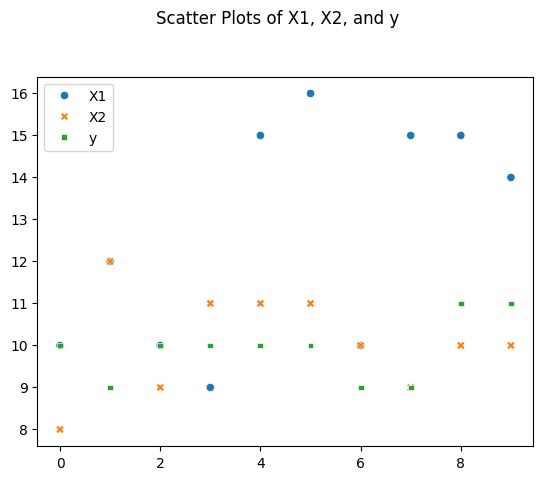

In [6]:
X1 = np.array([10, 12, 10, 9, 15, 16, 10, 15, 15, 14])
X2 = np.array([8, 12, 9, 11, 11, 11, 10, 9, 10, 10])
y = np.array([10, 9, 10, 10, 10, 10, 9, 9, 11, 11])

df1 = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})

print("--- Task 1a: First 5 rows ---")
print(df1.head())
sns.scatterplot(df1)
plt.suptitle("Scatter Plots of X1, X2, and y", y=1.02)
plt.show()

In [7]:
mean_X1 = np.mean(X1)
mean_X2 = np.mean(X2)
mean_y = np.mean(y)

var_X1 = np.sum((X1 - mean_X1)**2);
var_X2 = np.sum((X2 - mean_X2)**2)
cov_X1_y = np.sum((X1 - mean_X1) * (y - mean_y))
cov_X2_y = np.sum((X2 - mean_X2) * (y - mean_y))

b1 = cov_X1_y / var_X1
b2 = cov_X2_y / var_X2
b0 = mean_y - b1 * mean_X1 - b2 * mean_X2

print("--- Task 1b: Regression Coefficients (Direct Calculation) ---")
print(f"b0 (Intercept): {b0:.4f}")
print(f"b1 (Coefficient for X1): {b1:.4f}")
print(f"b2 (Coefficient for X2): {b2:.4f}")


--- Task 1b: Regression Coefficients (Direct Calculation) ---
b0 (Intercept): 9.7047
b1 (Coefficient for X1): 0.0714
b2 (Coefficient for X2): -0.0698


In [8]:
print("--- Task 1c: Regression Equation ---")
print(f"Equation: y = {b0:.4f} + ({b1:.4f})*X1 + ({b2:.4f})*X2")


--- Task 1c: Regression Equation ---
Equation: y = 9.7047 + (0.0714)*X1 + (-0.0698)*X2


In [10]:
y_pred = b0 + b1 * X1 + b2 * X2

# Residual Sum of Squares (RSS)
rss = np.sum((y - y_pred)**2)

# Root Mean Square Error (RMSE)
rmse = np.sqrt(np.mean((y - y_pred)**2))

# Total Sum of Squares (TSS) for R-squared
tss = np.sum((y - np.mean(y))**2)
r_squared = 1 - (rss / tss)

print(f"Residual Sum of Squares (RSS): {rss:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"Coefficient of Determination (R^2): {r_squared:.4f}")

Residual Sum of Squares (RSS): 4.4449
Root Mean Square Error (RMSE): 0.6667
Coefficient of Determination (R^2): 0.0929


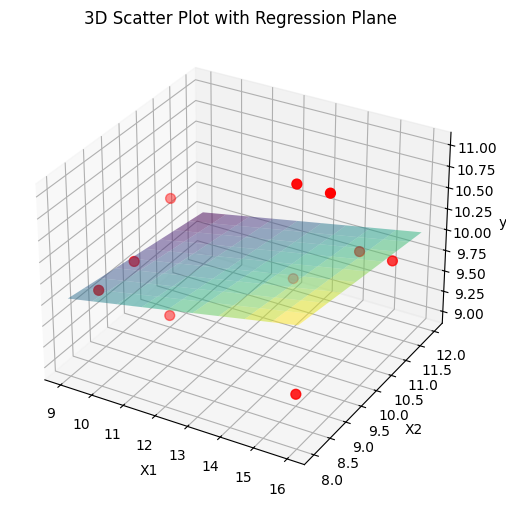

In [13]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual data
ax.scatter(X1, X2, y, color='red', label='Actual Data', s=50)

# Create a meshgrid for the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 10), 
                               np.linspace(X2.min(), X2.max(), 10))
y_surf = b0 + b1*x1_surf + b2*x2_surf

# Plot the surface
ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.5, cmap='viridis')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
plt.title('3D Scatter Plot with Regression Plane')
plt.show()

In [14]:
new_x1, new_x2 = 10, 11
predicted_y = b0 + b1*new_x1 + b2*new_x2


print(f"Predicted y for X1={new_x1} and X2={new_x2} is: {predicted_y:.4f}")

Predicted y for X1=10 and X2=11 is: 9.6515
